# Caso 2 — Wine Quality: calidad del vino tinto

**Universidad Andina del Cusco — Inteligencia Artificial (2026-II)**
Taller 1: Modelado Predictivo Multisectorial

**Contexto.** Predecir la calidad sensorial del vino tinto (escala 0–10, asignada por catadores) a partir de 11 propiedades fisico-quimicas medidas en laboratorio, sobre 1 143 muestras.

Este cuaderno recorre las dos fases exigidas por el enunciado:

- **Fase A** — limpieza, tratamiento de nulos, deteccion de outliers, analisis de
  multicolinealidad (matriz de correlacion y VIF) y estandarizacion.
- **Fase B** — entrenamiento y comparativa de **Regresion Lineal Multiple** y
  **Regresion Polinomial**, ambas bajo el mismo protocolo para que la comparacion
  sea legitima.

Semilla fija `random_state=42` en todo el cuaderno: los resultados son reproducibles.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print("Entorno listo")

Entorno listo


## Fase A — Analisis exploratorio y preprocesamiento

### Carga y limpieza

La columna `Id` es un identificador de fila: no aporta informacion predictiva y se elimina.

In [2]:
df = pd.read_csv("WineQT.csv")
print(f"Registros: {len(df)}   Columnas originales: {len(df.columns)}")
if "Id" in df.columns:
    df = df.drop(columns=["Id"])
    print("Columna 'Id' eliminada.")
OBJETIVO = "quality"
PREDICTORES = [c for c in df.columns if c != OBJETIVO]
print(f"Predictores: {len(PREDICTORES)}")
df.head()

Registros: 1143   Columnas originales: 13
Columna 'Id' eliminada.
Predictores: 11


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print(f"Nulos totales: {df.isna().sum().sum()}")
print(f"Duplicados: {df.duplicated().sum()}")
display(df.describe().T[["mean","std","min","50%","max"]].round(3))
print("\nDistribucion de la calidad (variable objetivo):")
print(df[OBJETIVO].value_counts().sort_index().to_string())

Nulos totales: 0
Duplicados: 125


,mean,std,min,50%,max
fixed acidity,8.311,1.748,4.600,7.900,15.900
volatile acidity,0.531,0.180,0.120,0.520,1.580
citric acid,0.268,0.197,0.000,0.250,1.000
residual sugar,2.532,1.356,0.900,2.200,15.500
chlorides,0.087,0.047,0.012,0.079,0.611
free sulfur dioxide,15.615,10.250,1.000,13.000,68.000
total sulfur dioxide,45.915,32.782,6.000,37.000,289.000
density,0.997,0.002,0.990,0.997,1.004
pH,3.311,0.157,2.740,3.310,4.010
sulphates,0.658,0.170,0.330,0.620,2.000



Distribucion de la calidad (variable objetivo):
quality
3      6
4     33
5    483
6    462
7    143
8     16


La calidad es **discreta y muy desbalanceada**: se concentra en 5 y 6. Esto acota de antemano el R² alcanzable por cualquier modelo de regresion.

### Deteccion de outliers (metodo IQR)

In [4]:
resumen = []
for c in PREDICTORES:
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    n = int(((df[c] < q1-1.5*iqr) | (df[c] > q3+1.5*iqr)).sum())
    resumen.append({"variable": c, "outliers": n, "%": round(100*n/len(df), 2)})
tabla = pd.DataFrame(resumen).set_index("variable").sort_values("outliers", ascending=False)
display(tabla)
print(f"Total de celdas atipicas: {tabla['outliers'].sum()} de {len(df)*len(PREDICTORES)}")

,outliers,%
variable,,
residual sugar,110,9.62
chlorides,77,6.74
fixed acidity,44,3.85
sulphates,43,3.76
total sulfur dioxide,40,3.50
density,36,3.15
pH,20,1.75
free sulfur dioxide,18,1.57
volatile acidity,14,1.22


Total de celdas atipicas: 415 de 12573


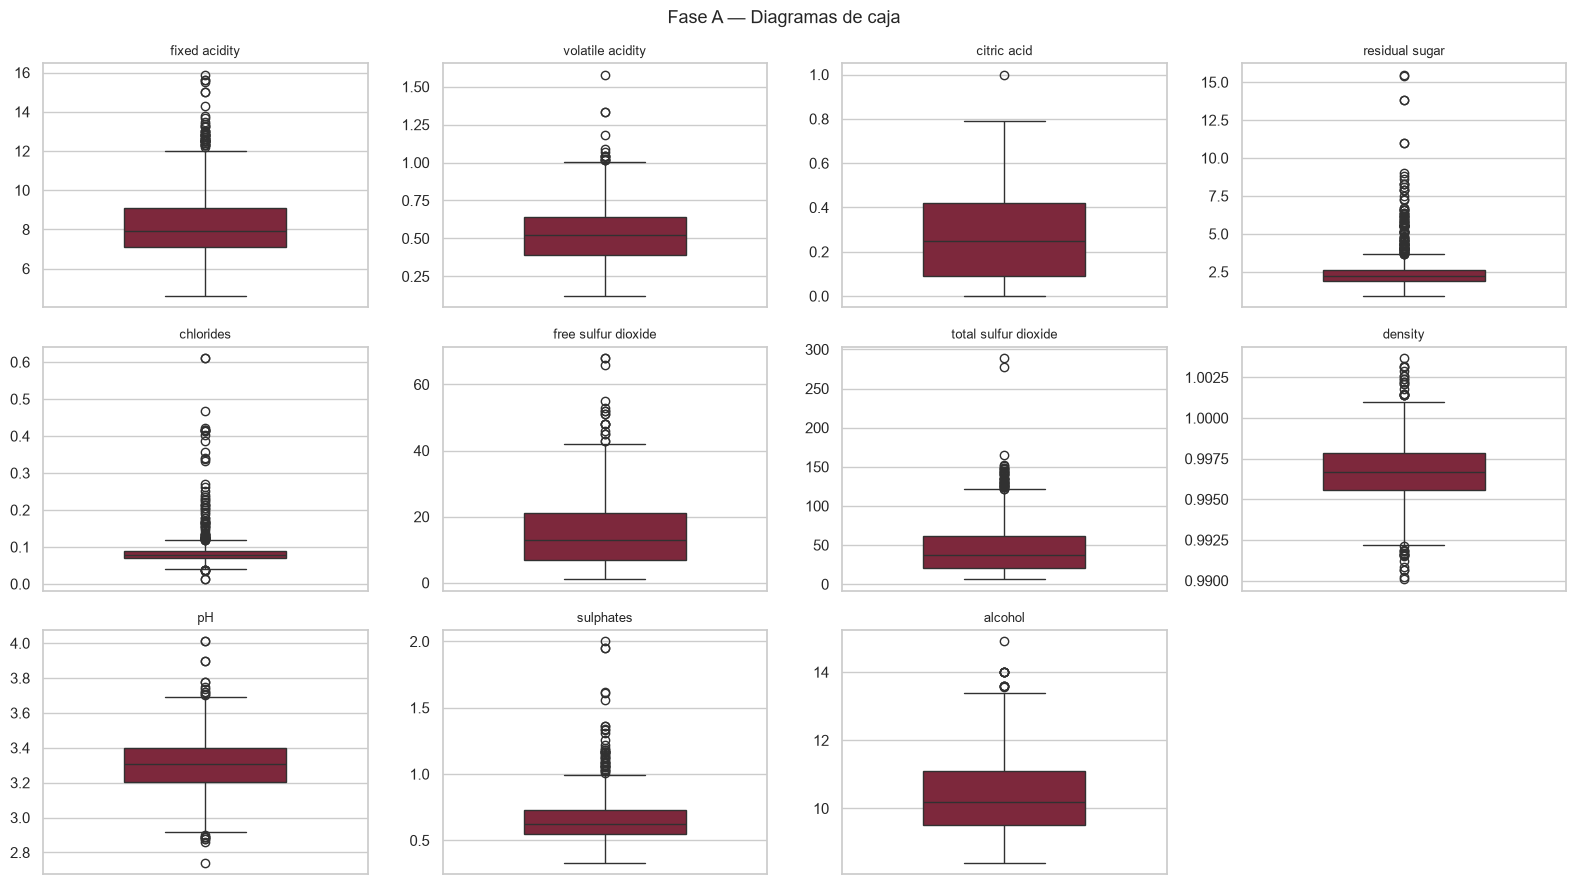

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, c in zip(axes.ravel(), PREDICTORES):
    sns.boxplot(y=df[c], ax=ax, color="#8b1a35", width=.5)
    ax.set_title(c, fontsize=9); ax.set_ylabel("")
for ax in axes.ravel()[len(PREDICTORES):]:
    ax.axis("off")
fig.suptitle("Fase A — Diagramas de caja", fontsize=13)
plt.tight_layout(); plt.show()

**Decision: se conservan.** Son composiciones quimicas reales; un vino puede tener acidez volatil alta y seguir siendo un vino valido. Con solo 1 143 muestras, eliminarlos reduciria una muestra ya pequena y sesgaria el modelo hacia el vino promedio.

### Multicolinealidad: matriz de correlacion y VIF

El **Factor de Inflacion de la Varianza** mide cuanto se infla la varianza del
coeficiente de una variable por estar correlacionada con las demas:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

donde $R^2_j$ es el ajuste al regresar la variable $j$ contra todas las otras.
La lectura habitual es: **VIF > 5** moderada, **VIF > 10** severa.

La multicolinealidad **no impide predecir**, pero hace inestables e
ininterpretables los coeficientes individuales.

In [6]:
def calcular_vif(X):
    """VIF_j = 1 / (1 - R2_j), regresando cada variable contra las demas."""
    Z = StandardScaler().fit_transform(X)
    vif = {}
    for j, nombre in enumerate(X.columns):
        otras = [k for k in range(Z.shape[1]) if k != j]
        r2 = LinearRegression().fit(Z[:, otras], Z[:, j]).score(Z[:, otras], Z[:, j])
        vif[nombre] = 1 / (1 - r2)
    return pd.Series(vif).sort_values(ascending=False)


def diagnostico(v):
    return "SEVERA" if v > 10 else ("moderada" if v > 5 else "aceptable")

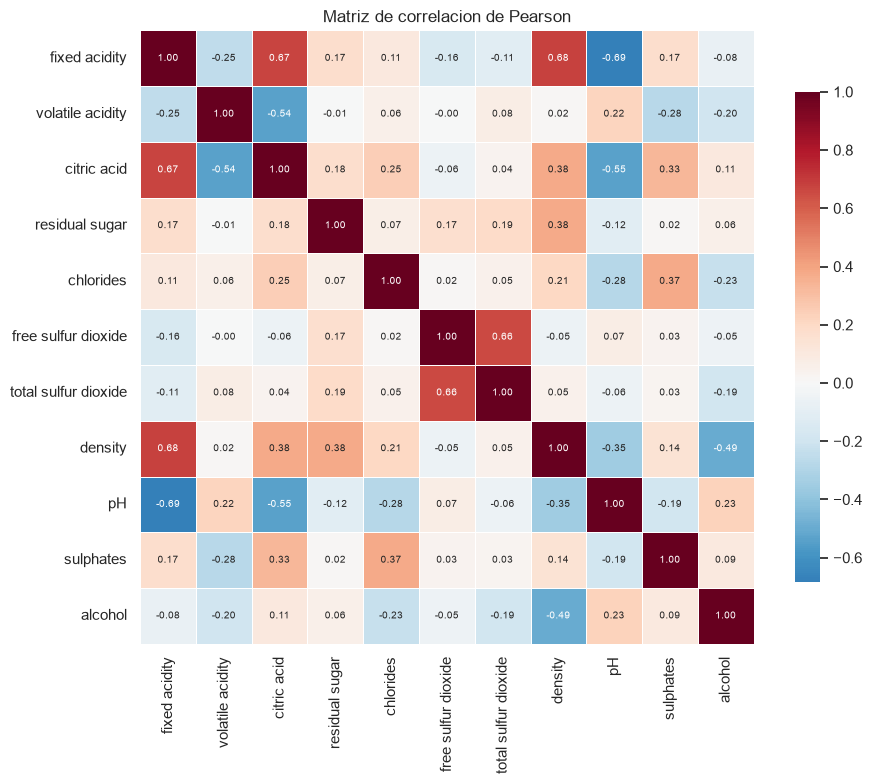

Pares con |r| > 0.5:
  fixed acidity          - citric acid            r = +0.6732
  fixed acidity          - density                r = +0.6815
  fixed acidity          - pH                     r = -0.6852
  volatile acidity       - citric acid            r = -0.5442
  citric acid            - pH                     r = -0.5463
  free sulfur dioxide    - total sulfur dioxide   r = +0.6611


In [7]:
corr = df[PREDICTORES].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
            linewidths=.5, ax=ax, cbar_kws={"shrink": .8}, annot_kws={"size": 7})
ax.set_title("Matriz de correlacion de Pearson"); plt.tight_layout(); plt.show()

print("Pares con |r| > 0.5:")
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > .5:
            print(f"  {corr.index[i]:<22} - {corr.columns[j]:<22} r = {corr.iloc[i,j]:+.4f}")

In [8]:
vif = calcular_vif(df[PREDICTORES])
display(pd.DataFrame({"VIF": vif.round(2), "diagnostico": vif.map(diagnostico)}))

print("\nCorrelacion de cada propiedad con la calidad:")
print(df[PREDICTORES + [OBJETIVO]].corr()[OBJETIVO].drop(OBJETIVO)
        .sort_values(ascending=False).round(4).to_string())

,VIF,diagnostico
fixed acidity,7.78,moderada
density,6.60,moderada
pH,3.39,aceptable
citric acid,3.22,aceptable
alcohol,3.18,aceptable
total sulfur dioxide,2.10,aceptable
free sulfur dioxide,1.91,aceptable
volatile acidity,1.78,aceptable
residual sugar,1.74,aceptable
chlorides,1.54,aceptable



Correlacion de cada propiedad con la calidad:
alcohol                 0.4849
sulphates               0.2577
citric acid             0.2408
fixed acidity           0.1220
residual sugar          0.0220
pH                     -0.0525
free sulfur dioxide    -0.0633
chlorides              -0.1241
density                -0.1752
total sulfur dioxide   -0.1833
volatile acidity       -0.4074


Ningun VIF supera 10: **no hay multicolinealidad severa** en este dataset, a diferencia de los casos 1 y 3. `alcohol` (+0.485) y `volatile acidity` (−0.407) son las propiedades mas asociadas a la calidad.

## Fase B — Modelamiento estadistico y comparativa

Se entrenan las **dos metodologias exigidas** compartiendo exactamente el mismo
preprocesamiento y la misma particion. La **unica** diferencia entre ellas es la
expansion polinomica, de modo que cualquier diferencia de rendimiento es
atribuible al modelo y no al tratamiento de los datos.

- **Regresion Lineal Multiple**: $\hat{y} = \beta_0 + \sum_i \beta_i z_i$
- **Regresion Polinomica grado 2**: anade terminos cuadraticos $z_i^2$ e
  interacciones $z_i z_j$. Sigue siendo **lineal en los parametros**, que es lo
  que define el metodo.

Se reportan tres medidas: R² de entrenamiento, R² de prueba y **R² de validacion
cruzada 5-fold**. La tercera es la mas fiable, porque promedia cinco particiones
distintas en lugar de depender de una sola.

In [9]:
def evaluar(nombre, grado, X_tr, X_te, y_tr, y_te, escala_dinero=False):
    """Entrena y evalua un modelo; grado=1 es la lineal multiple."""
    pasos = []
    if grado > 1:
        pasos.append(("poly", PolynomialFeatures(degree=grado, include_bias=False)))
    pasos += [("sc", StandardScaler()), ("modelo", LinearRegression())]
    pipe = Pipeline(pasos).fit(X_tr, y_tr)

    p_tr, p_te = pipe.predict(X_tr), pipe.predict(X_te)
    cv = cross_val_score(pipe, X_tr, y_tr, cv=CV, scoring="r2")
    return {
        "modelo": nombre,
        "terminos": pipe.named_steps["modelo"].coef_.size,
        "R2_train": round(r2_score(y_tr, p_tr), 4),
        "R2_test": round(r2_score(y_te, p_te), 4),
        "R2_CV": round(cv.mean(), 4),
        "CV_std": round(cv.std(), 4),
        "brecha": round(r2_score(y_tr, p_tr) - cv.mean(), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, p_te)), 4),
        "MAE": round(mean_absolute_error(y_te, p_te), 4),
    }, pipe

In [10]:
X, y = df[PREDICTORES], df[OBJETIVO]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
print(f"Entrenamiento: {len(X_tr)}   Prueba: {len(X_te)}   (80 / 20)")

Entrenamiento: 914   Prueba: 229   (80 / 20)


### Fase B.1 — Regresion Lineal Multiple

In [11]:
m_lin, pipe_lin = evaluar("Lineal multiple (OLS)", 1, X_tr, X_te, y_tr, y_te)
display(pd.Series(m_lin).to_frame("valor"))

co = pd.Series(pipe_lin.named_steps["modelo"].coef_, index=PREDICTORES)
print("Coeficientes (variables estandarizadas):")
print(co.reindex(co.abs().sort_values(ascending=False).index).round(4).to_string())

,valor
modelo,Lineal multiple (OLS)
terminos,11
R2_train,0.3822
R2_test,0.3171
R2_CV,0.3462
CV_std,0.0427
brecha,0.036
RMSE,0.6165
MAE,0.4773


Coeficientes (variables estandarizadas):
alcohol                 0.2864
volatile acidity       -0.2391
sulphates               0.1616
fixed acidity           0.0870
chlorides              -0.0856
total sulfur dioxide   -0.0729
citric acid            -0.0661
density                -0.0587
pH                     -0.0381
free sulfur dioxide     0.0192
residual sugar          0.0054


### Fase B.2 — Regresion Polinomica grado 2

Con 11 variables, la expansion de grado 2 genera 77 terminos: 11 lineales, 11 cuadraticos y 55 interacciones.

In [12]:
m_poly, pipe_poly = evaluar("Polinomica grado 2", 2, X_tr, X_te, y_tr, y_te)
pd.Series(m_poly).to_frame("valor")

,valor
modelo,Polinomica grado 2
terminos,77
R2_train,0.4591
R2_test,0.2809
R2_CV,0.2316
CV_std,0.1469
brecha,0.2275
RMSE,0.6326
MAE,0.4869


### Fase B.3 — Comparativa

,terminos,R2_train,R2_test,R2_CV,CV_std,brecha,RMSE,MAE
modelo,,,,,,,,
Lineal multiple (OLS),11,0.3822,0.3171,0.3462,0.0427,0.0360,0.6165,0.4773
Polinomica grado 2,77,0.4591,0.2809,0.2316,0.1469,0.2275,0.6326,0.4869


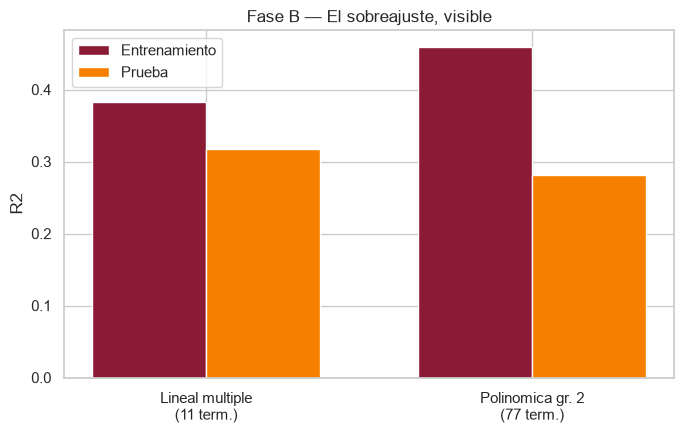

In [13]:
comp = pd.DataFrame([m_lin, m_poly]).set_index("modelo")
display(comp)

fig, ax = plt.subplots(figsize=(7, 4.5))
et = [f"Lineal multiple\n({m_lin['terminos']} term.)", f"Polinomica gr. 2\n({m_poly['terminos']} term.)"]
x, an = np.arange(2), .35
ax.bar(x - an/2, [m_lin["R2_train"], m_poly["R2_train"]], an, label="Entrenamiento", color="#8b1a35")
ax.bar(x + an/2, [m_lin["R2_test"], m_poly["R2_test"]], an, label="Prueba", color="#f77f00")
ax.set_xticks(x); ax.set_xticklabels(et); ax.set_ylabel("R2"); ax.legend()
ax.set_title("Fase B — El sobreajuste, visible"); plt.tight_layout(); plt.show()

### Conclusion del Caso 2

Caso de sobreajuste **de manual**: al pasar de 11 a 77 terminos el R² de entrenamiento
**sube** (+0.077) mientras el de prueba **baja** (−0.036) y el de validacion cruzada se
hunde. La brecha entrenamiento−CV se multiplica por seis.

Con 914 muestras de entrenamiento, 77 parametros son demasiados: el modelo memoriza el
ruido de la muestra en lugar de aprender la relacion.

**Modelo recomendado: Regresion Lineal Multiple.** El techo de R² ≈ 0.32 no es un defecto
del modelo sino del problema: la calidad es una puntuacion **subjetiva y discreta** asignada
por catadores, y 11 propiedades quimicas no pueden explicar por completo una valoracion
sensorial.